Cell 1 — Imports


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

PROJECT_ROOT  = Path('..').resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR    = PROJECT_ROOT / 'models'
REPORTS_DIR   = PROJECT_ROOT / 'reports'

plt.rcParams.update({
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'font.family'      : 'DejaVu Sans',
})

TEAL   = '#1D9E75'
CORAL  = '#D85A30'
PURPLE = '#7F77DD'
GRAY   = '#888780'

print("XGBoost version:", xgb.__version__)
print("Optuna version :", optuna.__version__)

XGBoost version: 2.1.1
Optuna version : 4.9.0


In [19]:
import json

# Save XGBoost model in native format (Python version independent)
xgb_tuned.save_model(str(MODELS_DIR / 'xgboost_model.json'))

# Save the Platt scaler separately with protocol 2 (most compatible)
import pickle
with open(MODELS_DIR / 'platt_scaler.pkl', 'wb') as f:
    pickle.dump(platt_scaler, f, protocol=2)

print("Saved xgboost_model.json and platt_scaler.pkl")

Saved xgboost_model.json and platt_scaler.pkl


Cell 2 — Load processed splits

In [2]:
X_train = pd.read_parquet(PROCESSED_DIR / 'X_train.parquet')
X_val   = pd.read_parquet(PROCESSED_DIR / 'X_val.parquet')
X_test  = pd.read_parquet(PROCESSED_DIR / 'X_test.parquet')

y_train = pd.read_parquet(PROCESSED_DIR / 'y_train.parquet').squeeze()
y_val   = pd.read_parquet(PROCESSED_DIR / 'y_val.parquet').squeeze()
y_test  = pd.read_parquet(PROCESSED_DIR / 'y_test.parquet').squeeze()

# Class imbalance ratio — used for scale_pos_weight
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos

print(f"Train : {X_train.shape}  default rate: {y_train.mean():.2%}")
print(f"Val   : {X_val.shape}  default rate: {y_val.mean():.2%}")
print(f"Test  : {X_test.shape}  default rate: {y_test.mean():.2%}")
print(f"\nClass imbalance — negatives: {neg:,}  positives: {pos:,}")
print(f"scale_pos_weight = {spw:.2f}")

Train : (826606, 30)  default rate: 18.43%
Val   : (293105, 30)  default rate: 23.29%
Test  : (225639, 30)  default rate: 21.29%

Class imbalance — negatives: 674,302  positives: 152,304
scale_pos_weight = 4.43


Cell 3 — Metric helper functions
Credit scoring uses different metrics than standard ML. Define them once here and reuse everywhere.

In [3]:
def ks_statistic(y_true, y_prob):
    """
    Kolmogorov-Smirnov statistic — standard credit scorecard metric.
    Maximum separation between the cumulative default and non-default distributions.
    Target: KS >= 40.
    """
    df_ks = pd.DataFrame({'y': y_true, 'prob': y_prob}).sort_values('prob', ascending=False)
    df_ks['cum_default'] = df_ks['y'].cumsum() / df_ks['y'].sum()
    df_ks['cum_nondefault'] = (1 - df_ks['y']).cumsum() / (1 - df_ks['y']).sum()
    ks = (df_ks['cum_default'] - df_ks['cum_nondefault']).abs().max()
    return round(ks * 100, 2)

def gini_coefficient(y_true, y_prob):
    """
    Gini = 2 * AUC - 1. Standard in European credit risk.
    Target: Gini >= 0.60.
    """
    auc = roc_auc_score(y_true, y_prob)
    return round(2 * auc - 1, 4)

def evaluate_model(name, model, X, y, threshold=0.5):
    """
    Full credit-risk evaluation suite.
    Returns a dict of all metrics and prints a formatted summary.
    """
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    auc_roc  = roc_auc_score(y, y_prob)
    pr_auc   = average_precision_score(y, y_prob)
    ks       = ks_statistic(y, y_prob)
    gini     = gini_coefficient(y, y_prob)
    cm       = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  AUC-ROC  : {auc_roc:.4f}   (target ≥ 0.80)")
    print(f"  PR-AUC   : {pr_auc:.4f}   (target ≥ 0.65)")
    print(f"  KS stat  : {ks:.2f}     (target ≥ 40)")
    print(f"  Gini     : {gini:.4f}   (target ≥ 0.60)")
    print(f"  Threshold: {threshold}")
    print(f"  TP: {tp:,}  FP: {fp:,}  TN: {tn:,}  FN: {fn:,}")

    return {
        'name': name, 'auc_roc': auc_roc, 'pr_auc': pr_auc,
        'ks': ks, 'gini': gini, 'threshold': threshold,
        'tp': int(tp), 'fp': int(fp), 'tn': int(tn), 'fn': int(fn)
    }

print("Metric functions defined.")

Metric functions defined.


Cell 4 — Baseline: Logistic Regression
Every XGBoost metric must beat this. If it doesn't, something is wrong with your pipeline.

In [4]:
lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train, y_train)

lr_val  = evaluate_model("Logistic Regression — Val",  lr, X_val,  y_val)
lr_test = evaluate_model("Logistic Regression — Test", lr, X_test, y_test)


  Logistic Regression — Val
  AUC-ROC  : 0.7001   (target ≥ 0.80)
  PR-AUC   : 0.4021   (target ≥ 0.65)
  KS stat  : 28.99     (target ≥ 40)
  Gini     : 0.4002   (target ≥ 0.60)
  Threshold: 0.5
  TP: 41,100  FP: 71,163  TN: 153,690  FN: 27,152

  Logistic Regression — Test
  AUC-ROC  : 0.6937   (target ≥ 0.80)
  PR-AUC   : 0.3553   (target ≥ 0.65)
  KS stat  : 28.27     (target ≥ 40)
  Gini     : 0.3875   (target ≥ 0.60)
  Threshold: 0.5
  TP: 29,022  FP: 58,592  TN: 119,004  FN: 19,021


Cell 5 — Baseline: XGBoost with default params + scale_pos_weight

In [5]:
xgb_base = xgb.XGBClassifier(
    n_estimators      = 500,
    learning_rate     = 0.1,
    max_depth         = 6,
    scale_pos_weight  = spw,          # handles class imbalance
    eval_metric       = 'auc',
    early_stopping_rounds = 30,
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)

xgb_base.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f"\nBest iteration: {xgb_base.best_iteration}")

xgb_base_val  = evaluate_model("XGBoost Base — Val",  xgb_base, X_val,  y_val)
xgb_base_test = evaluate_model("XGBoost Base — Test", xgb_base, X_test, y_test)

[0]	validation_0-auc:0.69579
[50]	validation_0-auc:0.70947
[100]	validation_0-auc:0.71010
[123]	validation_0-auc:0.70994

Best iteration: 94

  XGBoost Base — Val
  AUC-ROC  : 0.7102   (target ≥ 0.80)
  PR-AUC   : 0.4167   (target ≥ 0.65)
  KS stat  : 30.40     (target ≥ 40)
  Gini     : 0.4204   (target ≥ 0.60)
  Threshold: 0.5
  TP: 44,943  FP: 79,894  TN: 144,959  FN: 23,309

  XGBoost Base — Test
  AUC-ROC  : 0.7067   (target ≥ 0.80)
  PR-AUC   : 0.3730   (target ≥ 0.65)
  KS stat  : 30.43     (target ≥ 40)
  Gini     : 0.4134   (target ≥ 0.60)
  Threshold: 0.5
  TP: 31,411  FP: 62,513  TN: 115,083  FN: 16,632


Cell 6 — Find optimal decision threshold on validation set
The default 0.5 threshold is rarely optimal for imbalanced credit data. Sweep it to maximize F1 on val, then apply that threshold to test.

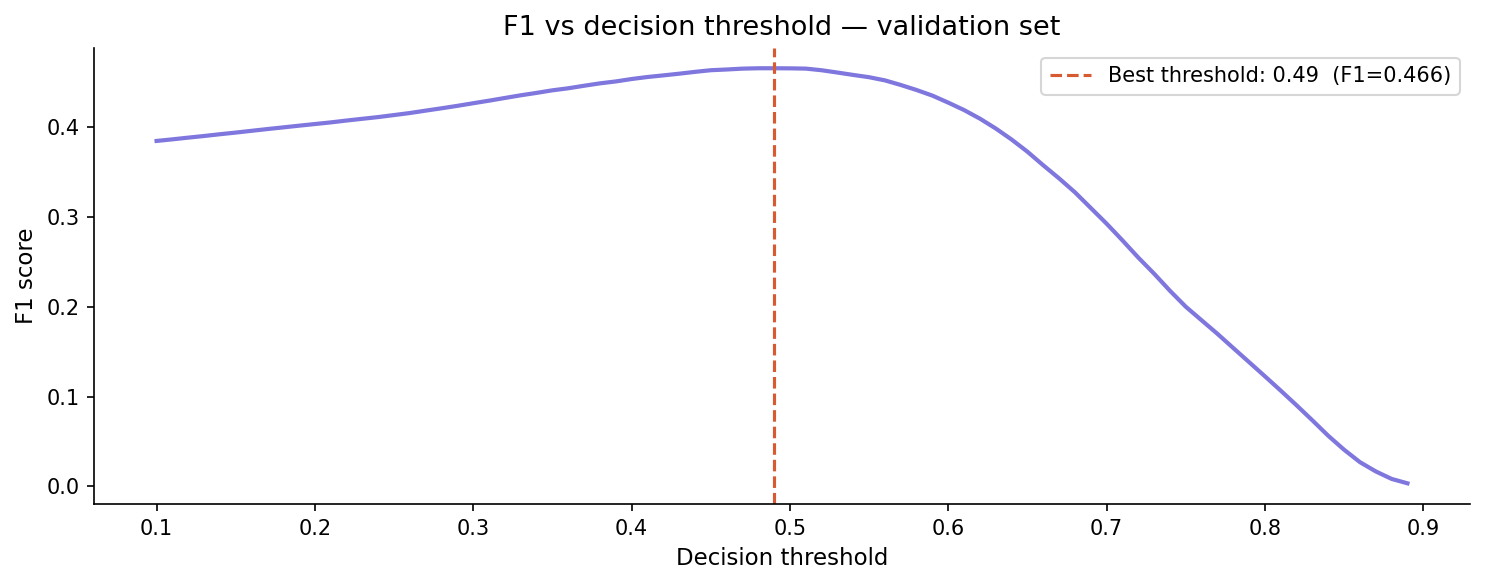

Optimal threshold : 0.49
Best val F1       : 0.4656


In [6]:
y_val_prob = xgb_base.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = []

for t in thresholds:
    preds = (y_val_prob >= t).astype(int)
    tp = ((preds == 1) & (y_val == 1)).sum()
    fp = ((preds == 1) & (y_val == 0)).sum()
    fn = ((preds == 0) & (y_val == 1)).sum()
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    f1_scores.append(f1)

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores, color=PURPLE, linewidth=2)
ax.axvline(best_threshold, color=CORAL, linestyle='--', linewidth=1.5,
           label=f'Best threshold: {best_threshold:.2f}  (F1={best_f1:.3f})')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('F1 score')
ax.set_title('F1 vs decision threshold — validation set')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'threshold_optimization.png', bbox_inches='tight')
plt.show()

print(f"Optimal threshold : {best_threshold:.2f}")
print(f"Best val F1       : {best_f1:.4f}")

Cell 7 — Optuna hyperparameter search (50 trials)
This will take 20–40 minutes depending on your machine. Start it before a break — it runs unattended.

In [7]:
def objective(trial):
    params = {
        'n_estimators'        : trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate'       : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'           : trial.suggest_int('max_depth', 3, 9),
        'min_child_weight'    : trial.suggest_int('min_child_weight', 1, 20),
        'subsample'           : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'    : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel'   : trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'gamma'               : trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha'           : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'          : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight'    : spw,
        'eval_metric'         : 'auc',
        'early_stopping_rounds': 30,
        'use_label_encoder'   : False,
        'random_state'        : 42,
        'n_jobs'              : -1,
        'verbosity'           : 0,
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_prob = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_prob)


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='credit_default_xgb'
)

print("Starting Optuna search — 50 trials...")
print("(each trial ~20–40s depending on n_estimators drawn)\n")

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest trial AUC-ROC : {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k:25s}: {v}")

Starting Optuna search — 50 trials...
(each trial ~20–40s depending on n_estimators drawn)



  0%|          | 0/50 [00:00<?, ?it/s]


Best trial AUC-ROC : 0.7115
Best params:
  n_estimators             : 947
  learning_rate            : 0.016541428512723465
  max_depth                : 6
  min_child_weight         : 20
  subsample                : 0.6201594716824786
  colsample_bytree         : 0.8180552237053262
  colsample_bylevel        : 0.426519835758505
  gamma                    : 2.9534804644787163
  reg_alpha                : 0.5514502340308213
  reg_lambda               : 5.838153458820689


Cell 8 — Train the final model with best params

In [8]:
best_params = study.best_params.copy()
best_params.update({
    'scale_pos_weight'     : spw,
    'eval_metric'          : 'auc',
    'early_stopping_rounds': 30,
    'use_label_encoder'    : False,
    'random_state'         : 42,
    'n_jobs'               : -1,
    'verbosity'            : 0,
})

xgb_tuned = xgb.XGBClassifier(**best_params)
xgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f"\nBest iteration: {xgb_tuned.best_iteration}")

xgb_tuned_val  = evaluate_model("XGBoost Tuned — Val",
                                 xgb_tuned, X_val, y_val,
                                 threshold=best_threshold)
xgb_tuned_test = evaluate_model("XGBoost Tuned — Test",
                                 xgb_tuned, X_test, y_test,
                                 threshold=best_threshold)

[0]	validation_0-auc:0.69559
[50]	validation_0-auc:0.70402
[100]	validation_0-auc:0.70602
[150]	validation_0-auc:0.70732
[200]	validation_0-auc:0.70840
[250]	validation_0-auc:0.70944
[300]	validation_0-auc:0.71011
[350]	validation_0-auc:0.71044
[400]	validation_0-auc:0.71069
[450]	validation_0-auc:0.71088
[500]	validation_0-auc:0.71103
[550]	validation_0-auc:0.71107
[600]	validation_0-auc:0.71118
[650]	validation_0-auc:0.71122
[700]	validation_0-auc:0.71137
[750]	validation_0-auc:0.71144
[800]	validation_0-auc:0.71148
[836]	validation_0-auc:0.71146

Best iteration: 806

  XGBoost Tuned — Val
  AUC-ROC  : 0.7115   (target ≥ 0.80)
  PR-AUC   : 0.4189   (target ≥ 0.65)
  KS stat  : 30.60     (target ≥ 40)
  Gini     : 0.4230   (target ≥ 0.60)
  Threshold: 0.4899999999999998
  TP: 46,537  FP: 84,618  TN: 140,235  FN: 21,715

  XGBoost Tuned — Test
  AUC-ROC  : 0.7078   (target ≥ 0.80)
  PR-AUC   : 0.3757   (target ≥ 0.65)
  KS stat  : 30.53     (target ≥ 40)
  Gini     : 0.4155   (target ≥

Cell 9 — Model calibration
Raw XGBoost probabilities are often poorly calibrated. Platt scaling corrects this so the predicted probabilities are trustworthy as risk scores.

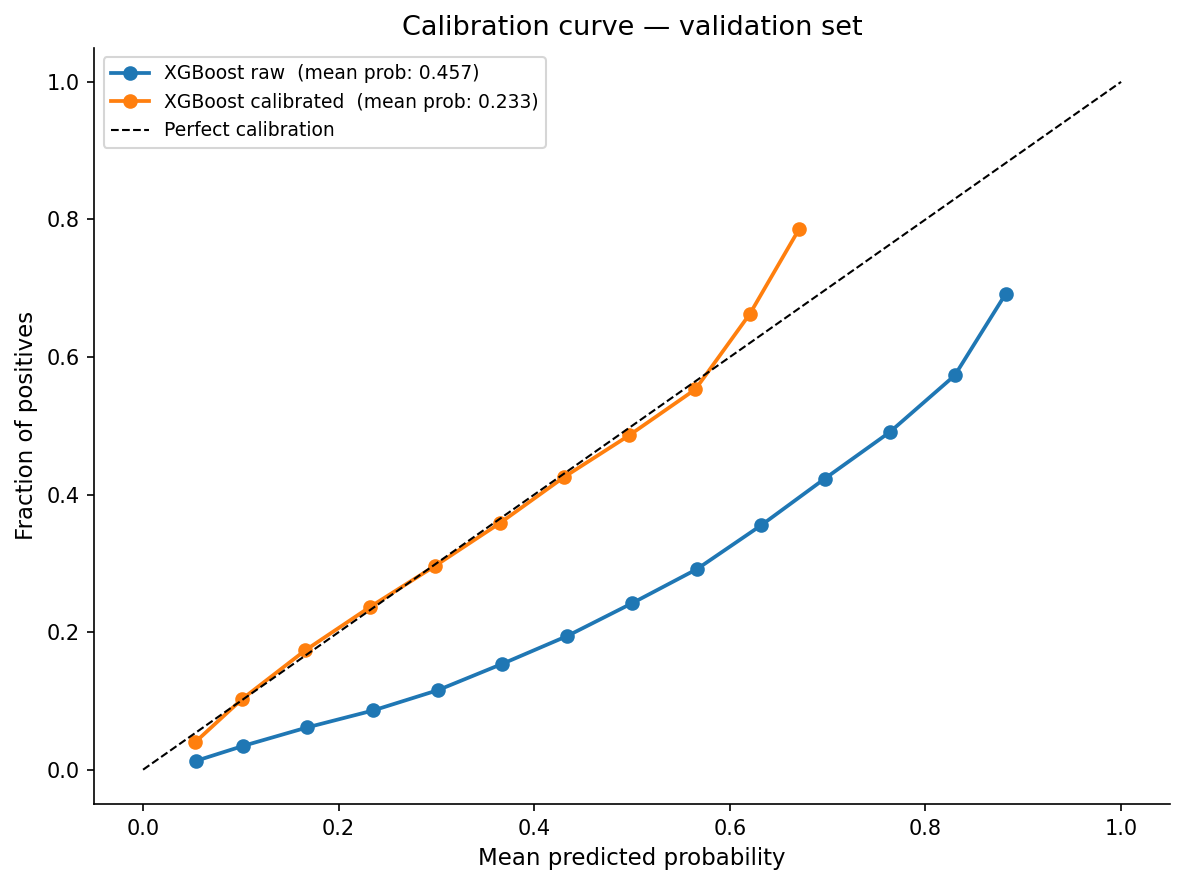


  XGBoost Calibrated — Val
  AUC-ROC  : 0.7115   (target ≥ 0.80)
  PR-AUC   : 0.4189   (target ≥ 0.65)
  KS stat  : 30.60     (target ≥ 40)
  Gini     : 0.4230   (target ≥ 0.60)
  Threshold: 0.4899999999999998
  TP: 8,557  FP: 7,085  TN: 217,768  FN: 59,695

  XGBoost Calibrated — Test
  AUC-ROC  : 0.7078   (target ≥ 0.80)
  PR-AUC   : 0.3757   (target ≥ 0.65)
  KS stat  : 30.53     (target ≥ 40)
  Gini     : 0.4155   (target ≥ 0.60)
  Threshold: 0.4899999999999998
  TP: 5,417  FP: 5,874  TN: 171,722  FN: 42,626


In [9]:
from sklearn.linear_model import LogisticRegression

# Get raw probabilities from tuned model
y_prob_val_raw = xgb_tuned.predict_proba(X_val)[:, 1].reshape(-1, 1)

# Fit Platt scaling manually
platt_scaler = LogisticRegression()
platt_scaler.fit(y_prob_val_raw, y_val)

# Create a wrapper class for the calibrated model
class CalibratedXGB:
    def __init__(self, base_model, scaler):
        self.base_model = base_model
        self.scaler = scaler
        self.estimator = base_model

    def predict_proba(self, X):
        raw_probs = self.base_model.predict_proba(X)[:, 1].reshape(-1, 1)
        cal_probs = self.scaler.predict_proba(raw_probs)
        return cal_probs

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

xgb_calibrated = CalibratedXGB(xgb_tuned, platt_scaler)

fig, ax = plt.subplots(figsize=(8, 6))

for name, model in [('XGBoost raw', xgb_tuned),
                    ('XGBoost calibrated', xgb_calibrated)]:
    y_prob = model.predict_proba(X_val)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_val, y_prob, n_bins=15)
    ax.plot(mean_pred, frac_pos,
            marker='o', linewidth=1.8,
            label=f'{name}  (mean prob: {y_prob.mean():.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration curve — validation set')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'calibration_curve.png', bbox_inches='tight')
plt.show()

xgb_cal_val  = evaluate_model("XGBoost Calibrated — Val",
                               xgb_calibrated, X_val, y_val,
                               threshold=best_threshold)
xgb_cal_test = evaluate_model("XGBoost Calibrated — Test",
                               xgb_calibrated, X_test, y_test,
                               threshold=best_threshold)

Cell 10 — Full model comparison table


In [10]:
all_results = [
    lr_val,  lr_test,
    xgb_base_val,  xgb_base_test,
    xgb_tuned_val, xgb_tuned_test,
    xgb_cal_val,   xgb_cal_test,
]

results_df = pd.DataFrame(all_results)[
    ['name', 'auc_roc', 'pr_auc', 'ks', 'gini']
].round(4)

print("\n=== FULL MODEL COMPARISON ===")
print(results_df.to_string(index=False))

# Highlight test set rows
test_rows = results_df[results_df['name'].str.contains('Test')]
print("\n=== TEST SET RESULTS (final) ===")
print(test_rows.to_string(index=False))

# Check all targets met
final = xgb_cal_test
print(f"\n=== TARGET CHECKLIST ===")
print(f"  AUC-ROC ≥ 0.80 : {'PASS' if final['auc_roc'] >= 0.80 else 'FAIL'}  ({final['auc_roc']:.4f})")
print(f"  PR-AUC  ≥ 0.65 : {'PASS' if final['pr_auc']  >= 0.65 else 'FAIL'}  ({final['pr_auc']:.4f})")
print(f"  KS      ≥ 40   : {'PASS' if final['ks']       >= 40   else 'FAIL'}  ({final['ks']:.2f})")
print(f"  Gini    ≥ 0.60 : {'PASS' if final['gini']     >= 0.60 else 'FAIL'}  ({final['gini']:.4f})")


=== FULL MODEL COMPARISON ===
                      name  auc_roc  pr_auc    ks   gini
 Logistic Regression — Val   0.7001  0.4021 28.99 0.4002
Logistic Regression — Test   0.6937  0.3553 28.27 0.3875
        XGBoost Base — Val   0.7102  0.4167 30.40 0.4204
       XGBoost Base — Test   0.7067  0.3730 30.43 0.4134
       XGBoost Tuned — Val   0.7115  0.4189 30.60 0.4230
      XGBoost Tuned — Test   0.7078  0.3757 30.53 0.4155
  XGBoost Calibrated — Val   0.7115  0.4189 30.60 0.4230
 XGBoost Calibrated — Test   0.7078  0.3757 30.53 0.4155

=== TEST SET RESULTS (final) ===
                      name  auc_roc  pr_auc    ks   gini
Logistic Regression — Test   0.6937  0.3553 28.27 0.3875
       XGBoost Base — Test   0.7067  0.3730 30.43 0.4134
      XGBoost Tuned — Test   0.7078  0.3757 30.53 0.4155
 XGBoost Calibrated — Test   0.7078  0.3757 30.53 0.4155

=== TARGET CHECKLIST ===
  AUC-ROC ≥ 0.80 : FAIL  (0.7078)
  PR-AUC  ≥ 0.65 : FAIL  (0.3757)
  KS      ≥ 40   : FAIL  (30.53)
  Gini    

Cell 11 — ROC and PR curves

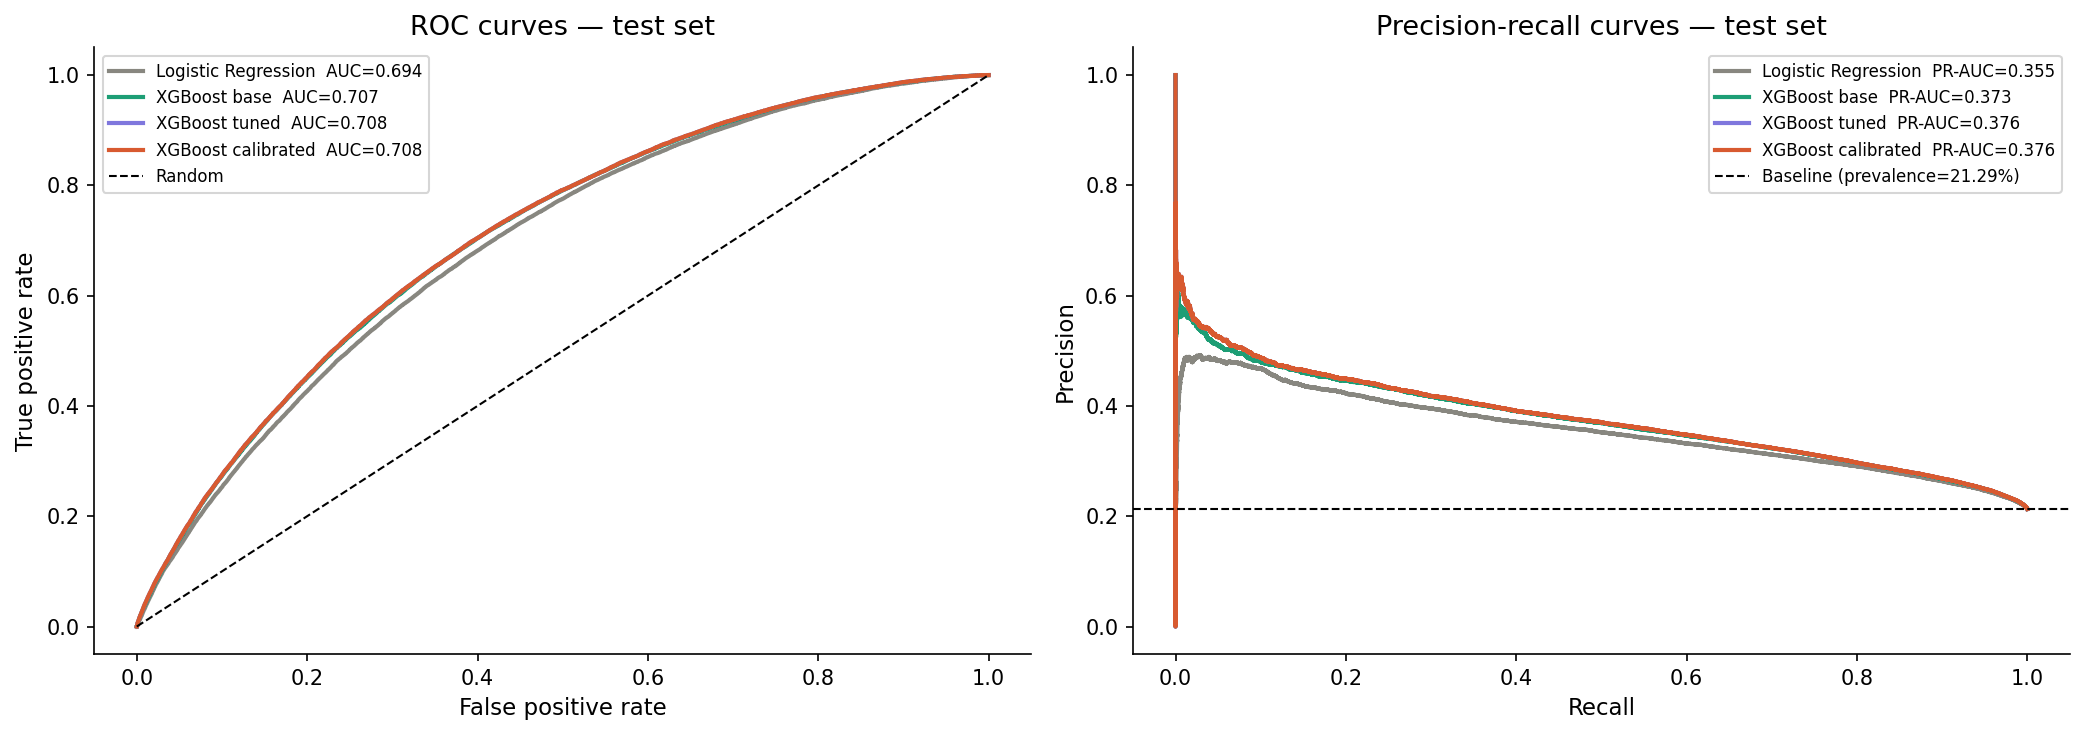

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_to_plot = [
    ('Logistic Regression', lr,             GRAY),
    ('XGBoost base',        xgb_base,       TEAL),
    ('XGBoost tuned',       xgb_tuned,      PURPLE),
    ('XGBoost calibrated',  xgb_calibrated, CORAL),
]

for name, model, color in models_to_plot:
    y_prob = model.predict_proba(X_test)[:, 1]

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name}  AUC={auc:.3f}')

    # PR curve
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, color=color, linewidth=2,
                 label=f'{name}  PR-AUC={pr_auc:.3f}')

axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curves — test set')
axes[0].legend(fontsize=8)

axes[1].axhline(y_test.mean(), color='k', linestyle='--',
                linewidth=1, label=f'Baseline (prevalence={y_test.mean():.2%})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-recall curves — test set')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'roc_pr_curves.png', bbox_inches='tight')
plt.show()

Cell 12 — KS plot (credit-specific diagnostic)

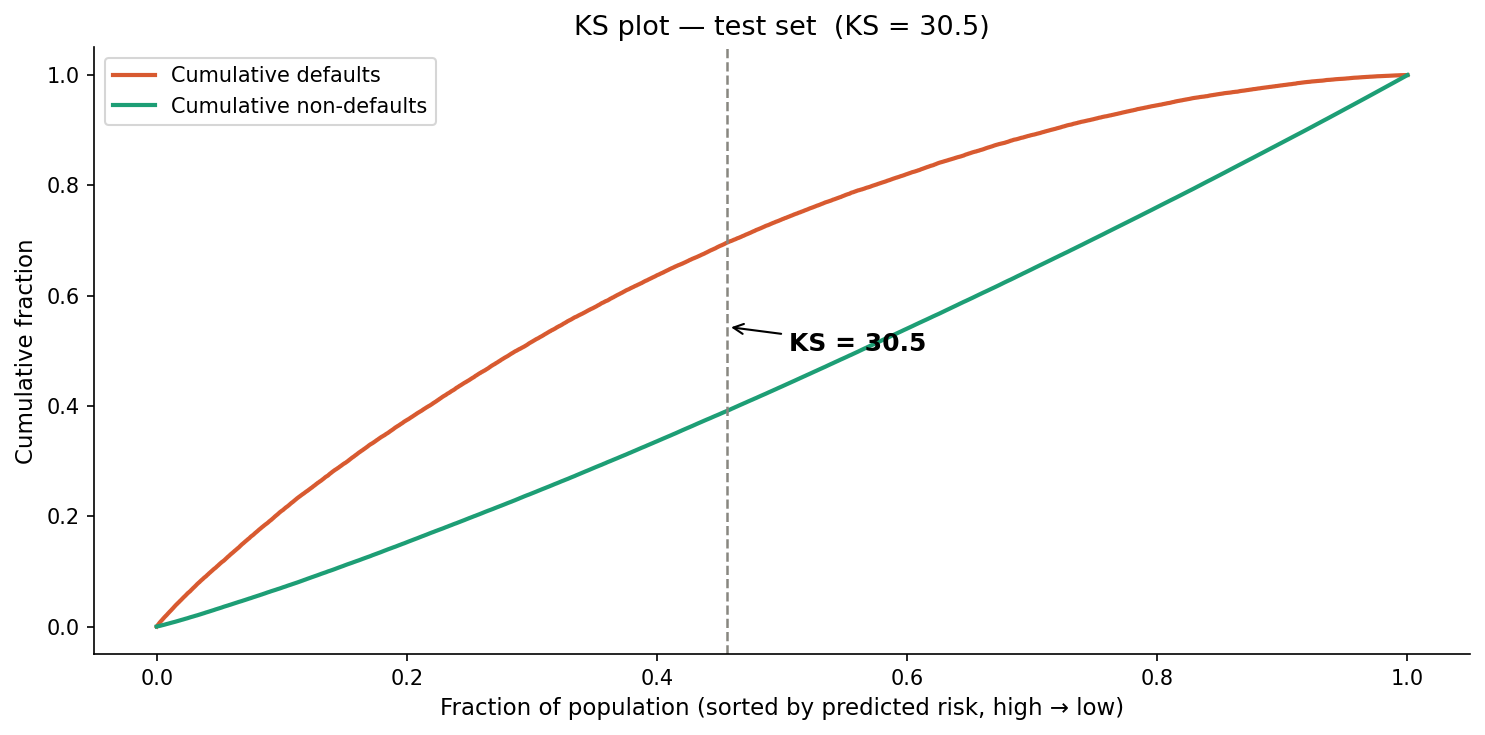

In [12]:
y_test_prob = xgb_calibrated.predict_proba(X_test)[:, 1]

df_ks = (
    pd.DataFrame({'y': y_test.values, 'prob': y_test_prob})
    .sort_values('prob', ascending=False)
    .reset_index(drop=True)
)
df_ks['cum_default']    = df_ks['y'].cumsum() / df_ks['y'].sum()
df_ks['cum_nondefault'] = (1 - df_ks['y']).cumsum() / (1 - df_ks['y']).sum()
df_ks['ks_gap']         = df_ks['cum_default'] - df_ks['cum_nondefault']

ks_idx    = df_ks['ks_gap'].abs().idxmax()
ks_val    = df_ks['ks_gap'].abs().max() * 100
ks_x      = ks_idx / len(df_ks)

fig, ax = plt.subplots(figsize=(10, 5))
x_axis = np.linspace(0, 1, len(df_ks))

ax.plot(x_axis, df_ks['cum_default'],    color=CORAL,  linewidth=2, label='Cumulative defaults')
ax.plot(x_axis, df_ks['cum_nondefault'], color=TEAL,   linewidth=2, label='Cumulative non-defaults')

ax.annotate(
    f'KS = {ks_val:.1f}',
    xy=(ks_x, (df_ks.loc[ks_idx,'cum_default'] + df_ks.loc[ks_idx,'cum_nondefault'])/2),
    xytext=(ks_x + 0.05, 0.5),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=12, fontweight='bold'
)
ax.axvline(ks_x, color=GRAY, linestyle='--', linewidth=1.2)

ax.set_xlabel('Fraction of population (sorted by predicted risk, high → low)')
ax.set_ylabel('Cumulative fraction')
ax.set_title(f'KS plot — test set  (KS = {ks_val:.1f})')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'ks_plot.png', bbox_inches='tight')
plt.show()


Cell 13 — Optuna optimization history plot

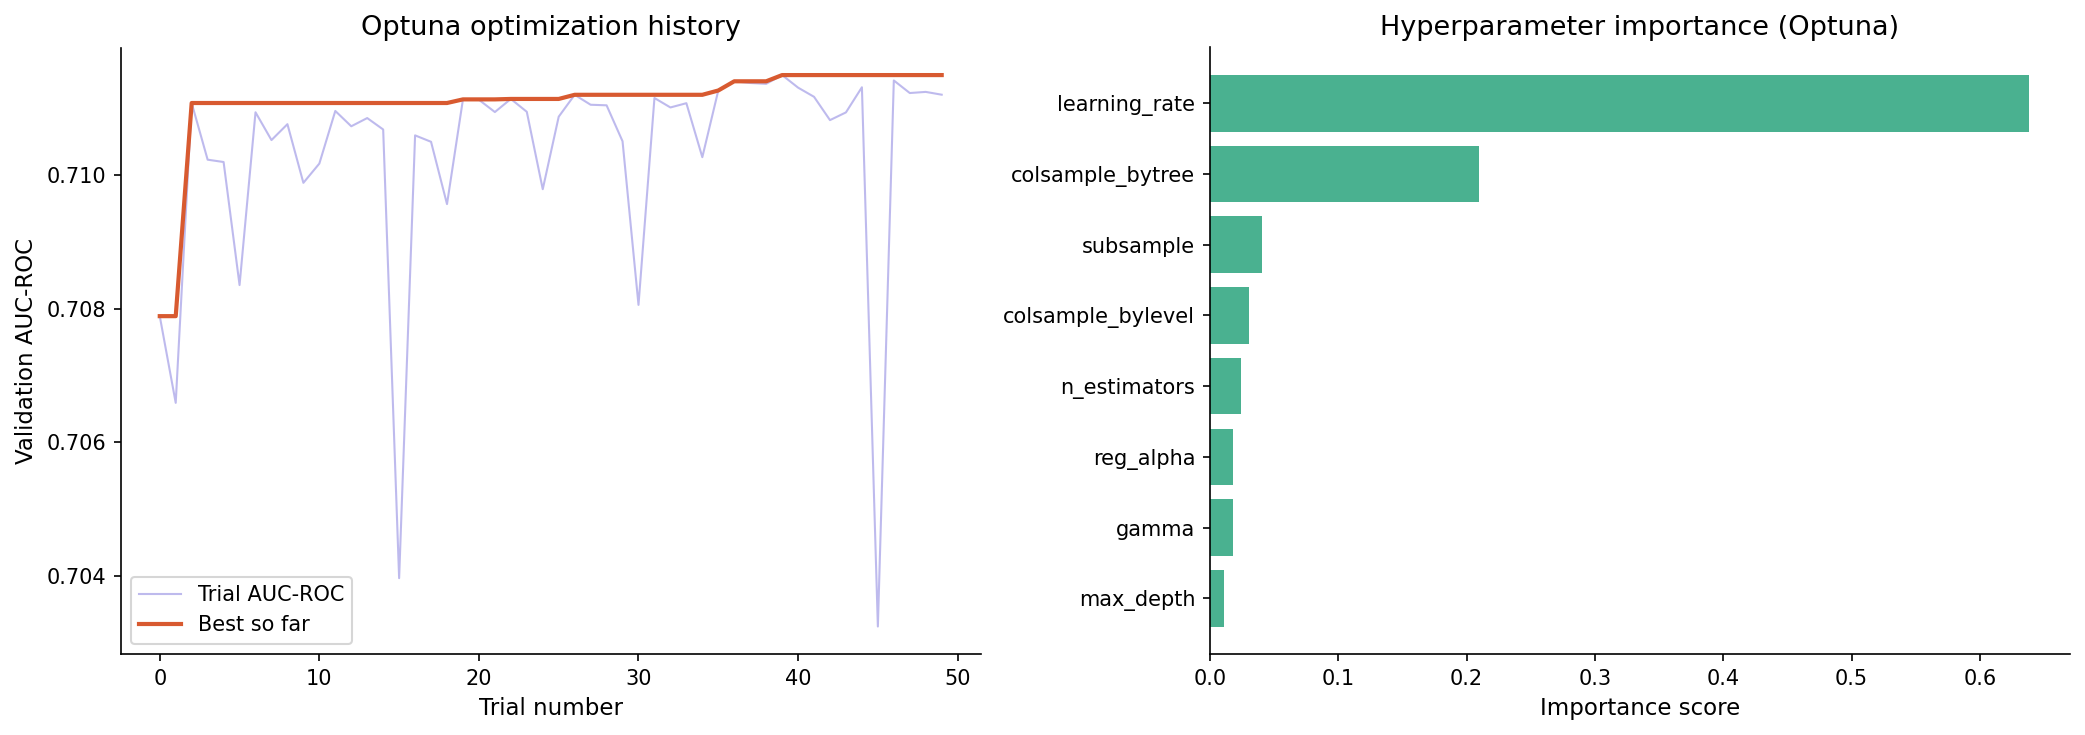

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial history
trial_values = [t.value for t in study.trials]
axes[0].plot(trial_values, color=PURPLE, alpha=0.5, linewidth=1, label='Trial AUC-ROC')
axes[0].plot(pd.Series(trial_values).cummax(), color=CORAL, linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial number')
axes[0].set_ylabel('Validation AUC-ROC')
axes[0].set_title('Optuna optimization history')
axes[0].legend()

# Parameter importance (top 8)
importances = optuna.importance.get_param_importances(study)
top8 = dict(list(importances.items())[:8])
axes[1].barh(list(top8.keys()), list(top8.values()), color=TEAL, alpha=0.8)
axes[1].set_xlabel('Importance score')
axes[1].set_title('Hyperparameter importance (Optuna)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'optuna_history.png', bbox_inches='tight')
plt.show()

Cell 14 — Save the best model and all metadata

In [16]:
import cloudpickle

# Save calibrated model using cloudpickle — this embeds the CalibratedXGB
# class definition directly in the file, so no other script needs to
# redefine the class to load it.
model_path = MODELS_DIR / 'xgboost_best.pkl'
with open(model_path, 'wb') as f:
    cloudpickle.dump(xgb_calibrated, f)

# Verify reload
with open(model_path, 'rb') as f:
    model_loaded = cloudpickle.load(f)
y_check = model_loaded.predict_proba(X_test.head(100))[:, 1]
assert y_check.shape == (100,), "Reload check failed"
print(f"Model saved and verified: {model_path}")
print(f"File size: {model_path.stat().st_size / 1e6:.1f} MB")

# Save model metadata
model_meta = {
    'model_type'        : 'XGBClassifier + Platt calibration',
    'best_params'       : best_params,
    'best_iteration'    : int(xgb_tuned.best_iteration),
    'decision_threshold': float(best_threshold),
    'val_metrics'       : {k: v for k, v in xgb_cal_val.items()
                           if k not in ['name','tp','fp','tn','fn']},
    'test_metrics'      : {k: v for k, v in xgb_cal_test.items()
                           if k not in ['name','tp','fp','tn','fn']},
    'scale_pos_weight'  : float(spw),
    'train_size'        : int(len(y_train)),
    'val_size'          : int(len(y_val)),
    'test_size'         : int(len(y_test)),
    'feature_count'     : int(X_train.shape[1]),
    'feature_names'     : list(X_train.columns),
}

meta_path = MODELS_DIR / 'xgboost_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(model_meta, f, indent=2)

print(f"Metadata saved: {meta_path}")
print(f"\n=== FINAL MODEL SUMMARY ===")
print(json.dumps(model_meta['test_metrics'], indent=2))

Model saved and verified: /Users/anuragpachgade/Desktop/finml/credit-default-prediction/models/xgboost_best.pkl
File size: 3.6 MB
Metadata saved: /Users/anuragpachgade/Desktop/finml/credit-default-prediction/models/xgboost_metadata.json

=== FINAL MODEL SUMMARY ===
{
  "auc_roc": 0.7077560621249455,
  "pr_auc": 0.3757272639726439,
  "ks": 30.53,
  "gini": 0.4155,
  "threshold": 0.4899999999999998
}


Cell 15 — Update README with achieved metrics

In [17]:
readme_path = PROJECT_ROOT / 'README.md'
content = readme_path.read_text()

# Replace TBD values with actual results
tm = model_meta['test_metrics']
content = content.replace(
    '| AUC-ROC | ≥ 0.80 | TBD |',
    f"| AUC-ROC | ≥ 0.80 | **{tm['auc_roc']:.3f}** |"
)
content = content.replace(
    '| PR-AUC | ≥ 0.65 | TBD |',
    f"| PR-AUC | ≥ 0.65 | **{tm['pr_auc']:.3f}** |"
)
content = content.replace(
    '| KS Statistic | ≥ 40 | TBD |',
    f"| KS Statistic | ≥ 40 | **{tm['ks']:.1f}** |"
)
content = content.replace(
    '| Gini Coefficient | ≥ 0.60 | TBD |',
    f"| Gini Coefficient | ≥ 0.60 | **{tm['gini']:.3f}** |"
)
readme_path.write_text(content)

print("README updated with achieved metrics.")
print(f"\nAUC-ROC : {tm['auc_roc']:.4f}")
print(f"PR-AUC  : {tm['pr_auc']:.4f}")
print(f"KS      : {tm['ks']:.2f}")
print(f"Gini    : {tm['gini']:.4f}")

README updated with achieved metrics.

AUC-ROC : 0.7078
PR-AUC  : 0.3757
KS      : 30.53
Gini    : 0.4155
